# 02 - Exploratory data analysis
**Business questions:** who creates the revenue, how do customers behave over time, and what separates customers who leave from customers who stay?

In [1]:
import sys, json, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import Markdown, display
from src.config import *
from src import eda, evaluation as ev
from src.feature_engineering import *
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)

In [2]:
customers = pd.read_csv(DATA_PROC / "customers_clean.csv", parse_dates=["customer_registration_date"])
tx = pd.read_csv(DATA_PROC / "transactions_clean.csv.gz", parse_dates=["date"])
orders = build_orders(tx); lines, returns = tx[~tx.is_return], tx[tx.is_return]
M = json.load(open(DATA_PROC / "metrics.json")); H = M["H"]
meta = json.load(open(DATA_PROC / "run_metadata.json"))
START, END = pd.Timestamp(M["data_start"]), pd.Timestamp(M["data_end"])
FEATURES_USED = meta["features_used"]
train_c = [pd.Timestamp(c) for c in M["train_cutoffs"]]; val_c = pd.Timestamp(M["val_cutoff"]); test_c = pd.Timestamp(M["test_cutoff"])
display(Markdown(f"> **Dataset: {meta['name']}** ({'SIMULATED' if meta['kind'] == 'synthetic' else 'real'}) | {M['data_start']} -> {M['data_end']} | churn window **{H} days** ({M['churn_window_source']}). "
                 "All numbers in the commentary below are computed from this dataset when the notebook runs."))

> **Dataset: synthetic_demo** (SIMULATED) | 2024-01-01 -> 2025-12-31 | churn window **90 days** (P95 of purchase gaps = 87 days, rounded up to a multiple of 15). All numbers in the commentary below are computed from this dataset when the notebook runs.

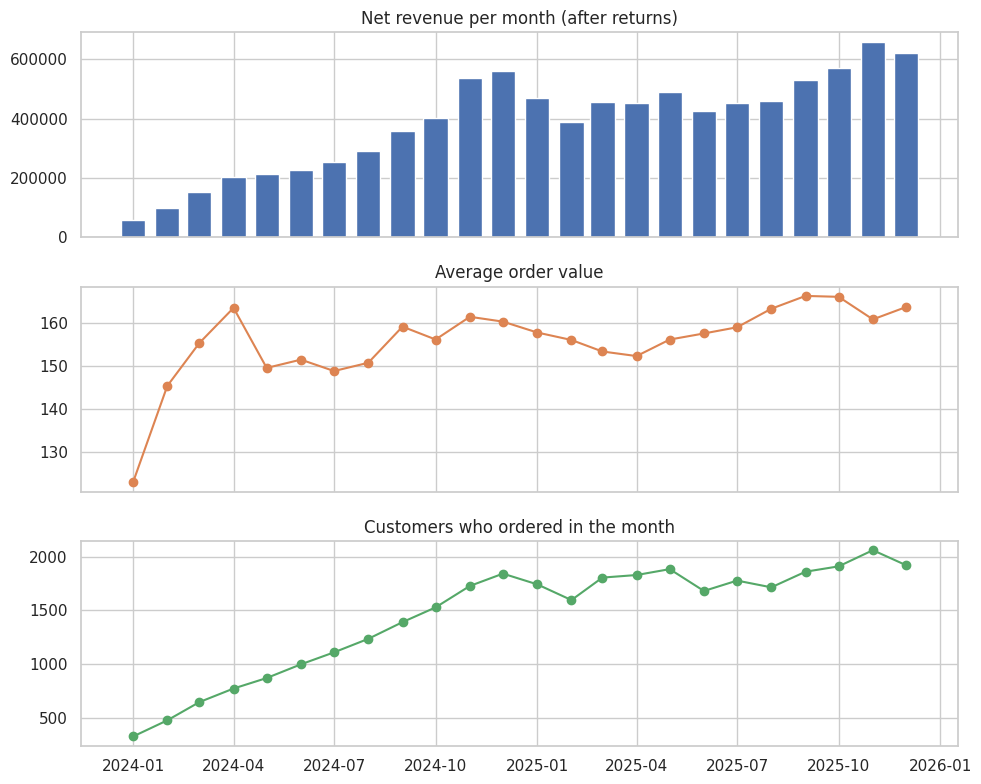

**So what?** Net revenue was 59,411 in the first month and 622,072 in the last; the strongest month is 2025-11 (658,365). Compare it with the customers-per-month panel: growth that only reflects a larger customer base is different from growth in spend per customer. Strong seasonal peaks also mean churn rates measured in different seasons are not directly comparable.

In [3]:
monthly = eda.monthly_summary(tx, orders)
eda.fig_revenue_trends(monthly); plt.show()
g = monthly.net_revenue
display(Markdown(f"**So what?** Net revenue was {g.iloc[0]:,.0f} in the first month and {g.iloc[-1]:,.0f} in the last; the strongest month is {g.idxmax():%Y-%m} ({g.max():,.0f}). "
                 "Compare it with the customers-per-month panel: growth that only reflects a larger customer base is different from growth in spend per customer. "
                 "Strong seasonal peaks also mean churn rates measured in different seasons are not directly comparable."))

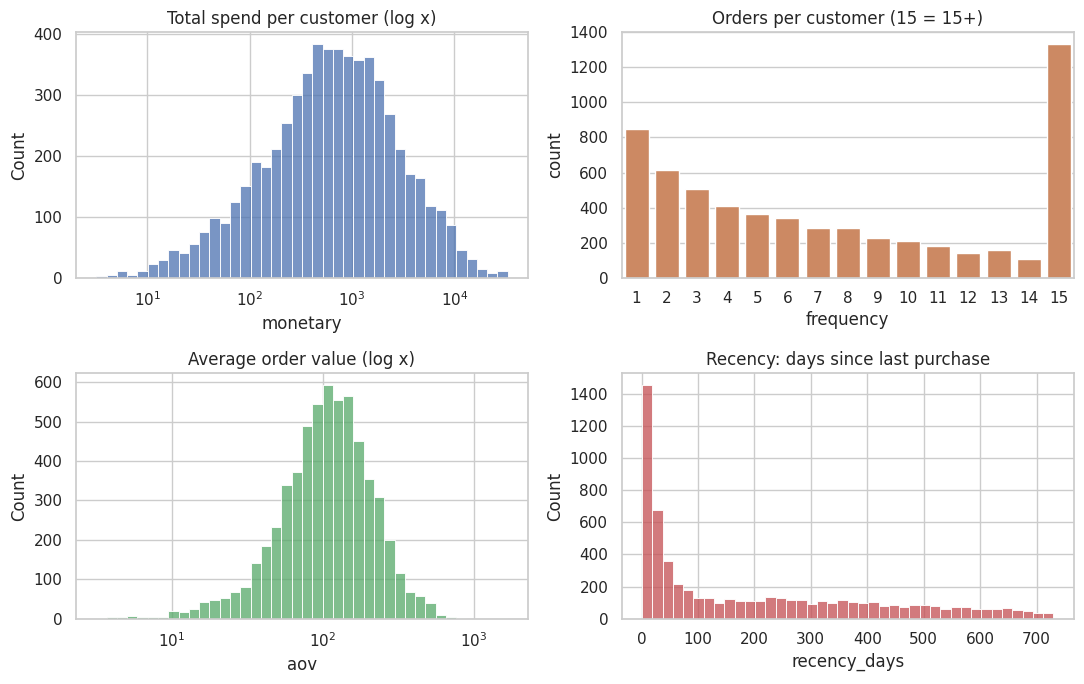

**So what?** Spending is extremely right-skewed: the top 20% of customers generate **69%** of revenue. Averages are therefore misleading, and any distance-based method (K-Means) needs log-scaling.

In [4]:
f = compute_features(orders, lines, returns, customers, END)
eda.fig_customer_distributions(f); plt.show()
s = f.monetary.sort_values(ascending=False)
top20 = s.head(int(.2 * len(s))).sum() / s.sum()
display(Markdown(f"**So what?** Spending is extremely right-skewed: the top 20% of customers generate **{top20:.0%}** of revenue. "
                 "Averages are therefore misleading, and any distance-based method (K-Means) needs log-scaling."))

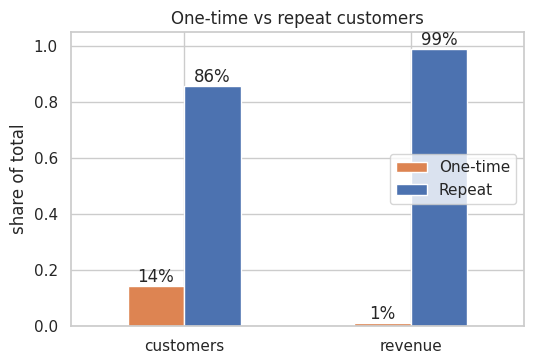

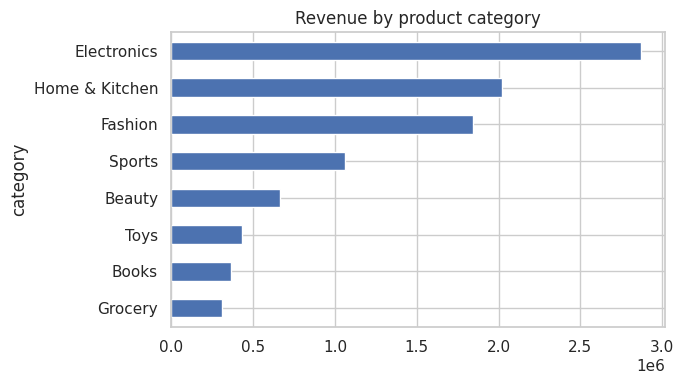

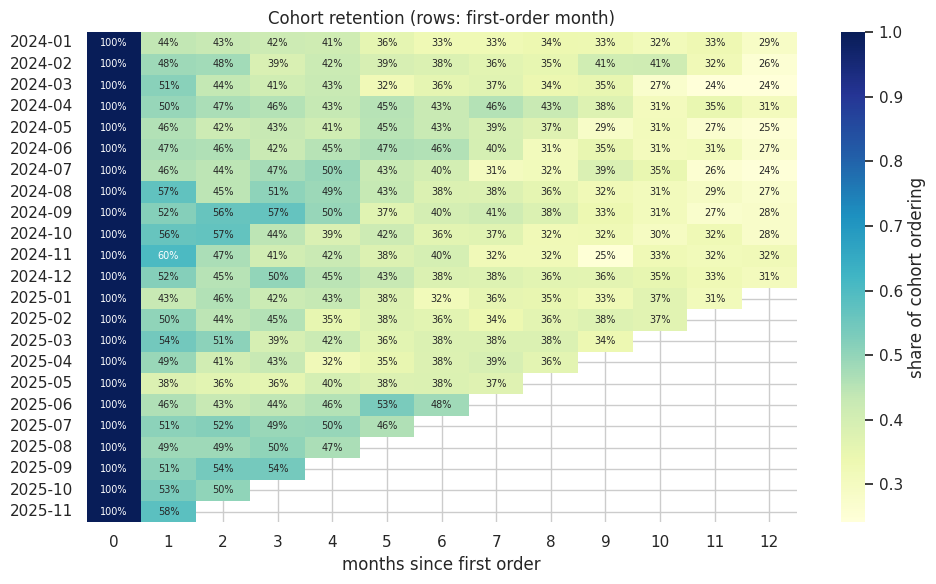

**So what?** 86% of customers bought at least twice. Read the cohort heatmap row by row: the first column is 100% by construction, the second shows how many customers come back in the month after their first purchase, and the right-hand side shows how fast activity fades. Retention work should consider both the first months after acquisition and long-tenured customers who go quiet.

In [5]:
eda.fig_repeat_vs_onetime(f); plt.show()
if meta["availability"]["category"]:
    eda.fig_category_revenue(tx); plt.show()
else:
    print("Revenue by category: Not available in this dataset")
eda.fig_cohort_retention(orders); plt.show()
rep = (f.frequency >= 2).mean()
display(Markdown(f"**So what?** {rep:.0%} of customers bought at least twice. Read the cohort heatmap row by row: the first column is 100% by construction, the second shows how many customers come back in the month after their first purchase, and the right-hand side shows how fast activity fades. "
                 "Retention work should consider both the first months after acquisition and long-tenured customers who go quiet."))

## Retention and churn
We now need the churn definition (developed fully in notebook 05). Here we only use it to compare behaviour. Features are computed at each cut-off using **past data only**.

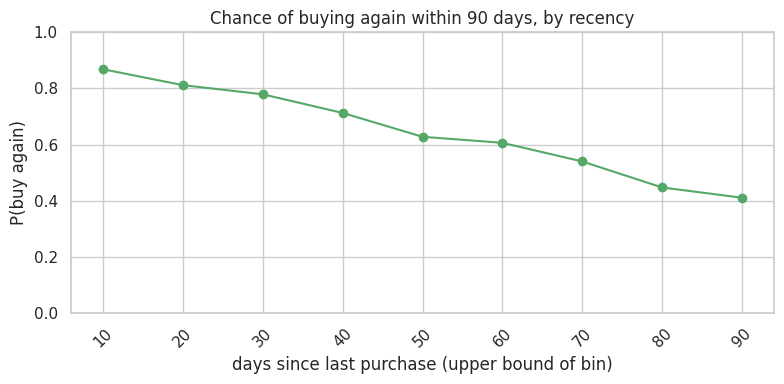

**So what?** Read the curve: it shows how the chance of buying again within 90 days changes with the time already silent. A steep decline means recency is a strong signal of future activity; a flat curve would mean it is not.

In [6]:
train = make_snapshots(orders, lines, returns, customers, train_c, H, data_end=END)
eda.fig_recency_vs_future(train, H); plt.show()
display(Markdown(f"**So what?** Read the curve: it shows how the chance of buying again within {H} days changes with the time already silent. A steep decline means recency is a strong signal of future activity; a flat curve would mean it is not."))

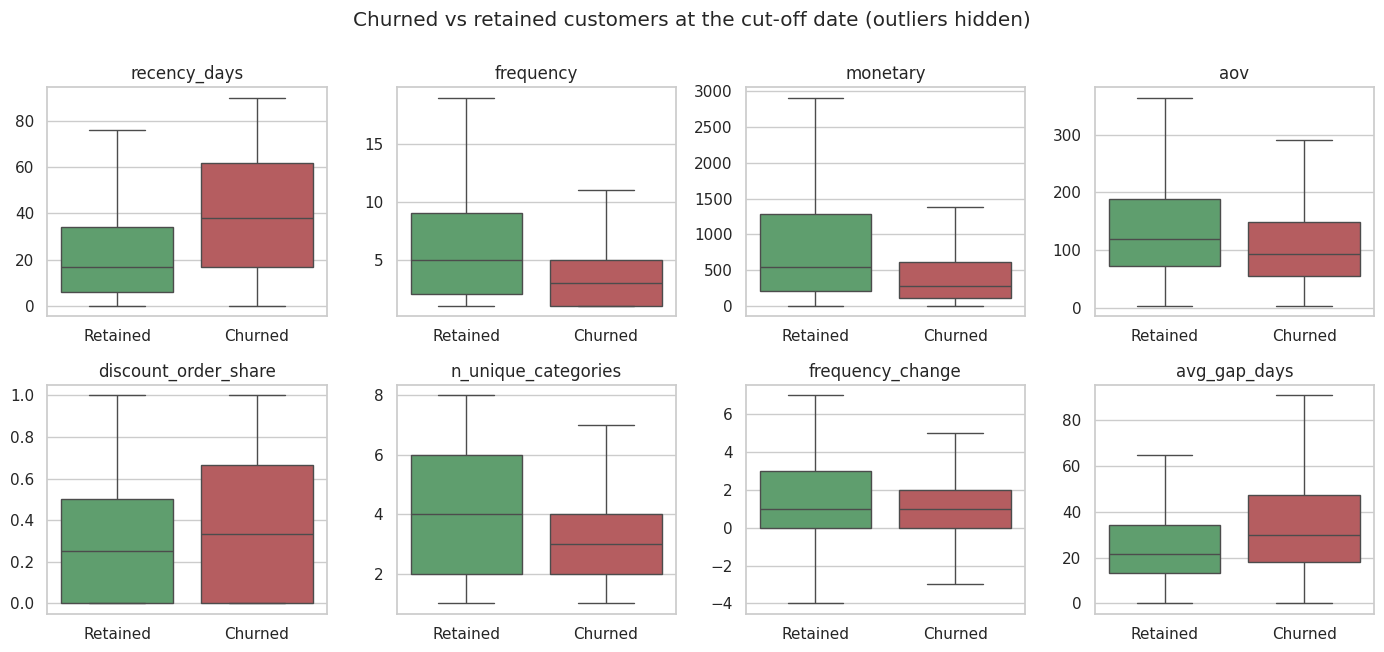

churned,Churned,Retained
recency_days,38.00,17.00
frequency,3.00,5.00
monetary,283.63,544.77
aov,92.72,119.19
avg_gap_days,30.00,21.67
discount_order_share,0.33,0.25
n_unique_categories,3.00,4.00
n_unique_products,5.00,9.00
frequency_change,1.00,1.00


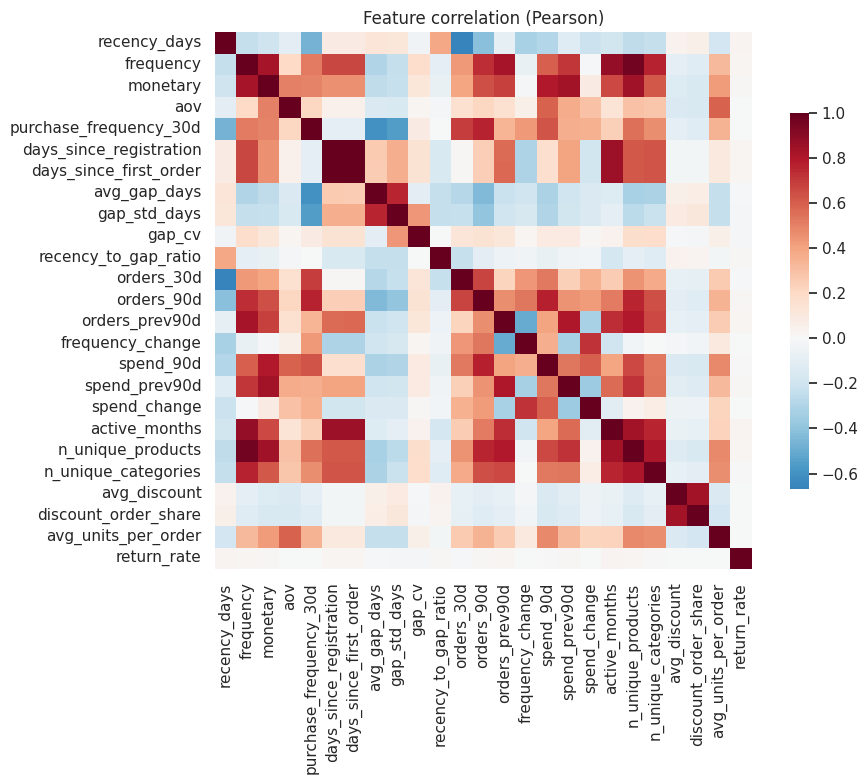

In [7]:
eda.fig_churn_vs_retained(train, FEATURES_USED); plt.show()
cols = [c for c in ["recency_days","frequency","monetary","aov","avg_gap_days","discount_order_share","n_unique_categories","n_unique_products","frequency_change"] if c in FEATURES_USED]
med = train.groupby(train.churned.map({0:"Retained",1:"Churned"}))[cols].median()
display(med.T.round(2))
eda.fig_corr(train, FEATURES_USED); plt.show()
excl = meta["features_excluded"]
if excl: print("Features not available / not used in this dataset:", {k: v for k, v in excl.items()})

In [8]:
bul = []
for c in med.columns:
    ch, rt = med.loc["Churned", c], med.loc["Retained", c]
    bul.append(f"* `{c}`: median {ch:,.2f} for churned vs {rt:,.2f} for retained ({'higher' if ch > rt else 'lower' if ch < rt else 'equal'} among churned)")
display(Markdown("### So what?\n" + "\n".join(bul) + "\n\n"
    "* These are *associations at a point in time*, not causes: e.g. a different discount share between groups does not show that discounts cause churn.\n"
    "* Many predictors are correlated (frequency, spend, 90-day orders...). That is fine for tree models, but individual linear coefficients and importances must be read with care."))

### So what?
* `recency_days`: median 38.00 for churned vs 17.00 for retained (higher among churned)
* `frequency`: median 3.00 for churned vs 5.00 for retained (lower among churned)
* `monetary`: median 283.63 for churned vs 544.77 for retained (lower among churned)
* `aov`: median 92.72 for churned vs 119.19 for retained (lower among churned)
* `avg_gap_days`: median 30.00 for churned vs 21.67 for retained (higher among churned)
* `discount_order_share`: median 0.33 for churned vs 0.25 for retained (higher among churned)
* `n_unique_categories`: median 3.00 for churned vs 4.00 for retained (lower among churned)
* `n_unique_products`: median 5.00 for churned vs 9.00 for retained (lower among churned)
* `frequency_change`: median 1.00 for churned vs 1.00 for retained (equal among churned)

* These are *associations at a point in time*, not causes: e.g. a different discount share between groups does not show that discounts cause churn.
* Many predictors are correlated (frequency, spend, 90-day orders...). That is fine for tree models, but individual linear coefficients and importances must be read with care.